# 04 · Differential expression analysis (DEA)
**Input :** `data/processed/adata_annotated.h5ad`  
**Output:** `data/processed/dea_results.csv` · `results/figures/volcano_plot.png`

Wilcoxon rank-sum test comparing tumor (HCC2) vs normal-adjacent (HCC1).

**Run order:** 03 → **04** → 05 → P1 → P2 → P3 → P4


In [1]:
import sys
from pathlib import Path

def _find_repo_root(start):
    for p in [start, *start.parents]:
        if (p / "paths.py").exists():
            return p
    raise FileNotFoundError("paths.py not found — run: python scripts/data_download.py")

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "scripts"))

from paths import REPO_ROOT, RAW_DIR, PROC_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR
print(f"Repo root : {REPO_ROOT}")
print(f"Raw data  : {RAW_DIR}")

Repo root : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD
Raw data  : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\raw


In [2]:
import scanpy as sc
from utils import run_wilcoxon, plot_volcano, export_dea

In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
PADJ_THRESH   = 0.05
LOG2FC_THRESH = 1.0
GROUP         = "tumor (HCC2)"   # test group (vs all others)
GROUPBY       = "sample"

## 1 · Load

In [4]:
adata = sc.read(str(PROC_DIR / "adata_annotated.h5ad"))
print(adata)

AnnData object with n_obs × n_vars = 2795 × 33694
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden_res_0.30', 'leiden_res_0.50', 'leiden_res_1.00', 'leiden_res_2.00', 'celltypist_coarse', 'celltypist_fine', 'sctype_cell_type', 'SingleR_HPCA', 'manual_celltype'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'celltypist_coarse_colors', 'celltypist_fin

## 2 · Wilcoxon DEA

In [5]:
sig, de_results = run_wilcoxon(
    adata,
    groupby=GROUPBY,
    group=GROUP,
    padj_thresh=PADJ_THRESH,
    log2fc_thresh=LOG2FC_THRESH,
)
sig.head(10)

Total DEGs    : 1385
Upregulated   : 335
Downregulated : 1050


,gene,scores,log2FC,pvalue,adj_pvalue,regulation
0,RPS26,26.308933,1.991955,1.515576e-152,7.295115e-149,up
1,XIST,23.464739,31.180847,9.349445e-122,2.625168e-118,up
2,MALAT1,20.834894,1.089554,2.089721e-96,3.200503e-93,up
3,CREM,19.406971,2.918553,6.738461e-84,7.829163e-81,up
4,JUND,18.446568,1.322786,5.556331e-76,5.349000e-73,up
6,RP11-138A9.2,16.519718,3.155438,2.646311e-61,1.621178e-58,up
7,HLA-C,16.483912,1.089220,4.788466e-61,2.881117e-58,up
8,ZFP36L2,16.010973,2.108820,1.071225e-57,5.552903e-55,up
9,BTG1,15.975739,1.349612,1.886050e-57,9.484859e-55,up
10,SRSF7,15.574635,1.745543,1.082697e-54,5.211486e-52,up


## 3 · Volcano plot

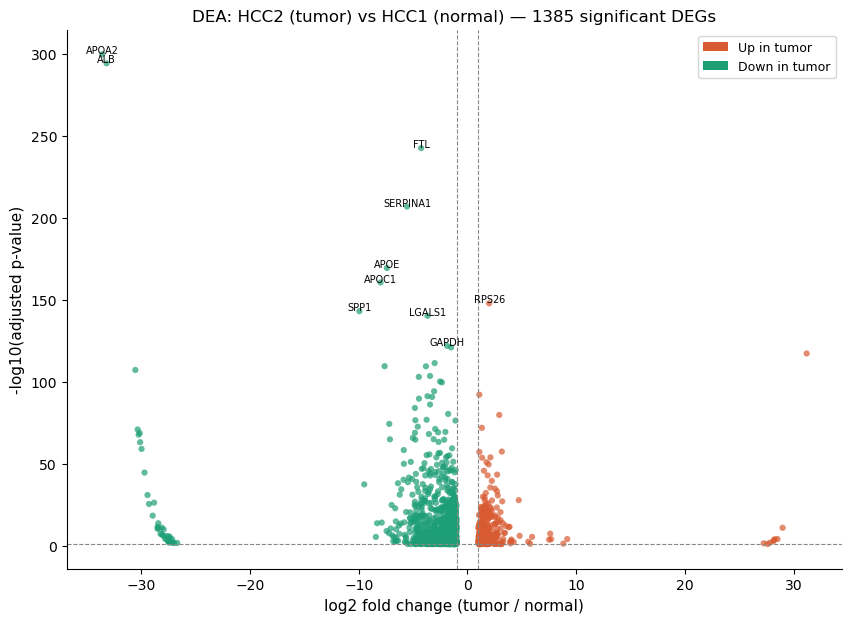

Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures/volcano_plot.png


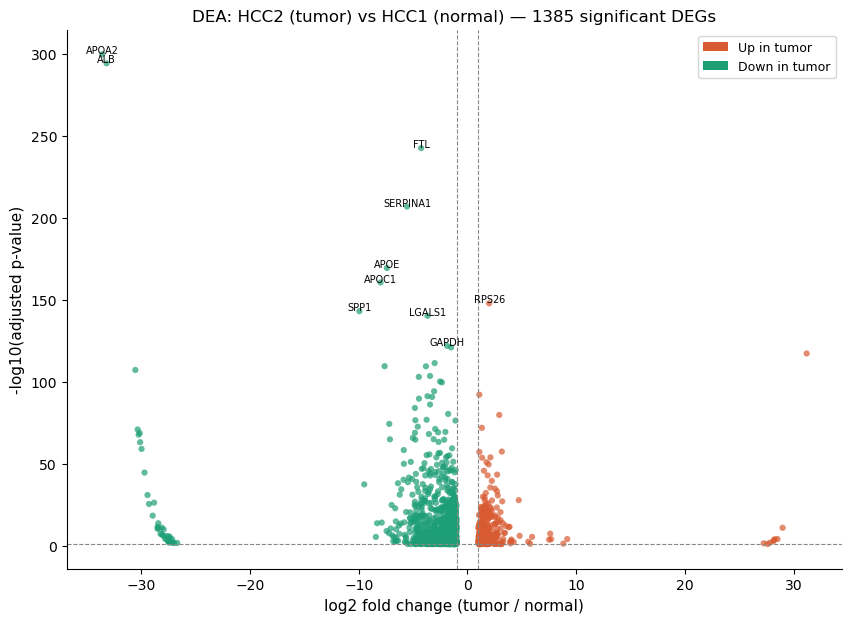

In [6]:
plot_volcano(sig, FIGURES_DIR)

## 4 · Export

In [7]:
export_dea(sig, PROC_DIR)

Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\processed\dea_results.csv  (1385 DEGs)

Top 5 upregulated:
   gene    log2FC    adj_pvalue
   XIST 31.180847 2.625168e-118
  OLFM4 28.968952  4.820013e-12
  ADH1C 28.503433  3.367689e-05
   TFF2 28.247526  4.383444e-05
CEACAM6 28.181561  1.653879e-04

Top 5 downregulated:
  gene     log2FC    adj_pvalue
 APOA2 -33.587166  0.000000e+00
   ALB -33.181702 3.627433e-295
RPS4Y1 -30.532921 2.993306e-108
 FABP1 -30.319868  5.665009e-72
  AHSG -30.232588  7.987003e-69
